In [1]:
# Work from the project root, so the Datasets/ and models/ paths below resolve the same
# whether this notebook is opened from notebooks/ or from the root.
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed — skipping XGB model.')

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('SHAP not installed — skipping SHAP explainability section.')

sns.set_theme(style='whitegrid')
SEED = 42

In [2]:
from sklearn.model_selection import train_test_split

DROP_COLS = ['Name', 'Email', 'Review']

df = pd.read_csv('Datasets/Churn.csv')

# Churn.csv sometimes has a stray duplicated header row baked into the data
# (Churn == 'Churn'), which forces every numeric column to load as object dtype.
# Casting to str before the isin() check makes this filter work whether Churn
# loaded as int64 (clean file) or object (file still has the bad row).
df = df[df['Churn'].astype(str).isin(['0', '1'])].reset_index(drop=True)

df['Churn'] = df['Churn'].astype(int)
df['Account_Age_Days'] = df['Account_Age_Days'].astype(int)
df['Daily_Usage_Mins'] = df['Daily_Usage_Mins'].astype(int)
df['Support_Tickets_90Days'] = df['Support_Tickets_90Days'].astype(int)
df['API_Utilization_Rate'] = df['API_Utilization_Rate'].astype(float)

df = df.drop(columns=DROP_COLS)

# Engineered ratio feature — captures interactions the raw columns can't express
# individually (especially for the linear model, which can't form ratios on its own).
# +1 in the denominator guards the Daily_Usage_Mins == 0 rows.
df['Support_Ticket_Friction'] = df['Support_Tickets_90Days'] / (df['Daily_Usage_Mins'] + 1)

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

train, temp = train_test_split(
    df, test_size=(1 - TRAIN_FRAC), stratify=df['Churn'], random_state=SEED
)
val, test = train_test_split(
    temp, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=temp['Churn'], random_state=SEED
)

train.to_csv('Datasets/train_churn.csv', index=False)
val.to_csv('Datasets/validation_churn.csv', index=False)
test.to_csv('Datasets/test_churn.csv', index=False)

print(f'Train:      {train.shape}  ({len(train)/len(df):.1%})')
print(f'Validation: {val.shape}  ({len(val)/len(df):.1%})')
print(f'Test:       {test.shape}  ({len(test)/len(df):.1%})')
train.head()

Train:      (1749, 9)  (70.0%)
Validation: (375, 9)  (15.0%)
Test:       (376, 9)  (15.0%)


,Customer_ID,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Plan_Tier,Support_Tickets_90Days,API_Utilization_Rate,Churn,Support_Ticket_Friction
649,10b54cc2-95f1-4520-8d06-12c58dc14449,1018,Daily,65,Enterprise,1,0.62,0,0.015152
308,2168308b-9154-402f-b502-bc2910e31d5f,1026,Daily,27,Enterprise,7,0.55,0,0.250000
207,1fde5ab1-0bca-420d-9682-8450f11ca7ee,806,Weekly,56,Pro,2,0.53,0,0.035088
36,48ec32bc-1afa-485c-aa67-2d5da7703402,183,Weekly,30,Pro,3,0.42,0,0.096774
2132,2e72b727-907a-4126-b618-c0429be15b94,56,Daily,53,Basic,2,0.24,1,0.037037


In [3]:
print(train.dtypes)
print('\nMissing values:')
print(train.isnull().sum())
print('\nChurn distribution:')
print(train['Churn'].value_counts(normalize=True).round(3))

Customer_ID                 object
Account_Age_Days             int64
Login_Frequency             object
Daily_Usage_Mins             int64
Plan_Tier                   object
Support_Tickets_90Days       int64
API_Utilization_Rate       float64
Churn                        int64
Support_Ticket_Friction    float64
dtype: object

Missing values:
Customer_ID                0
Account_Age_Days           0
Login_Frequency            0
Daily_Usage_Mins           0
Plan_Tier                  0
Support_Tickets_90Days     0
API_Utilization_Rate       0
Churn                      0
Support_Ticket_Friction    0
dtype: int64

Churn distribution:
Churn
0    0.637
1    0.363
Name: proportion, dtype: float64


In [4]:
neg, pos = (train['Churn'] == 0).sum(), (train['Churn'] == 1).sum()
imbalance_ratio = neg / pos

print(f'Retained (0): {neg}  |  Churned (1): {pos}')
print(f'Imbalance ratio (retained : churned) = {imbalance_ratio:.2f} : 1')
print(f'Majority-class baseline accuracy      = {neg / (neg + pos):.1%}')

Retained (0): 1114  |  Churned (1): 635
Imbalance ratio (retained : churned) = 1.75 : 1
Majority-class baseline accuracy      = 63.7%


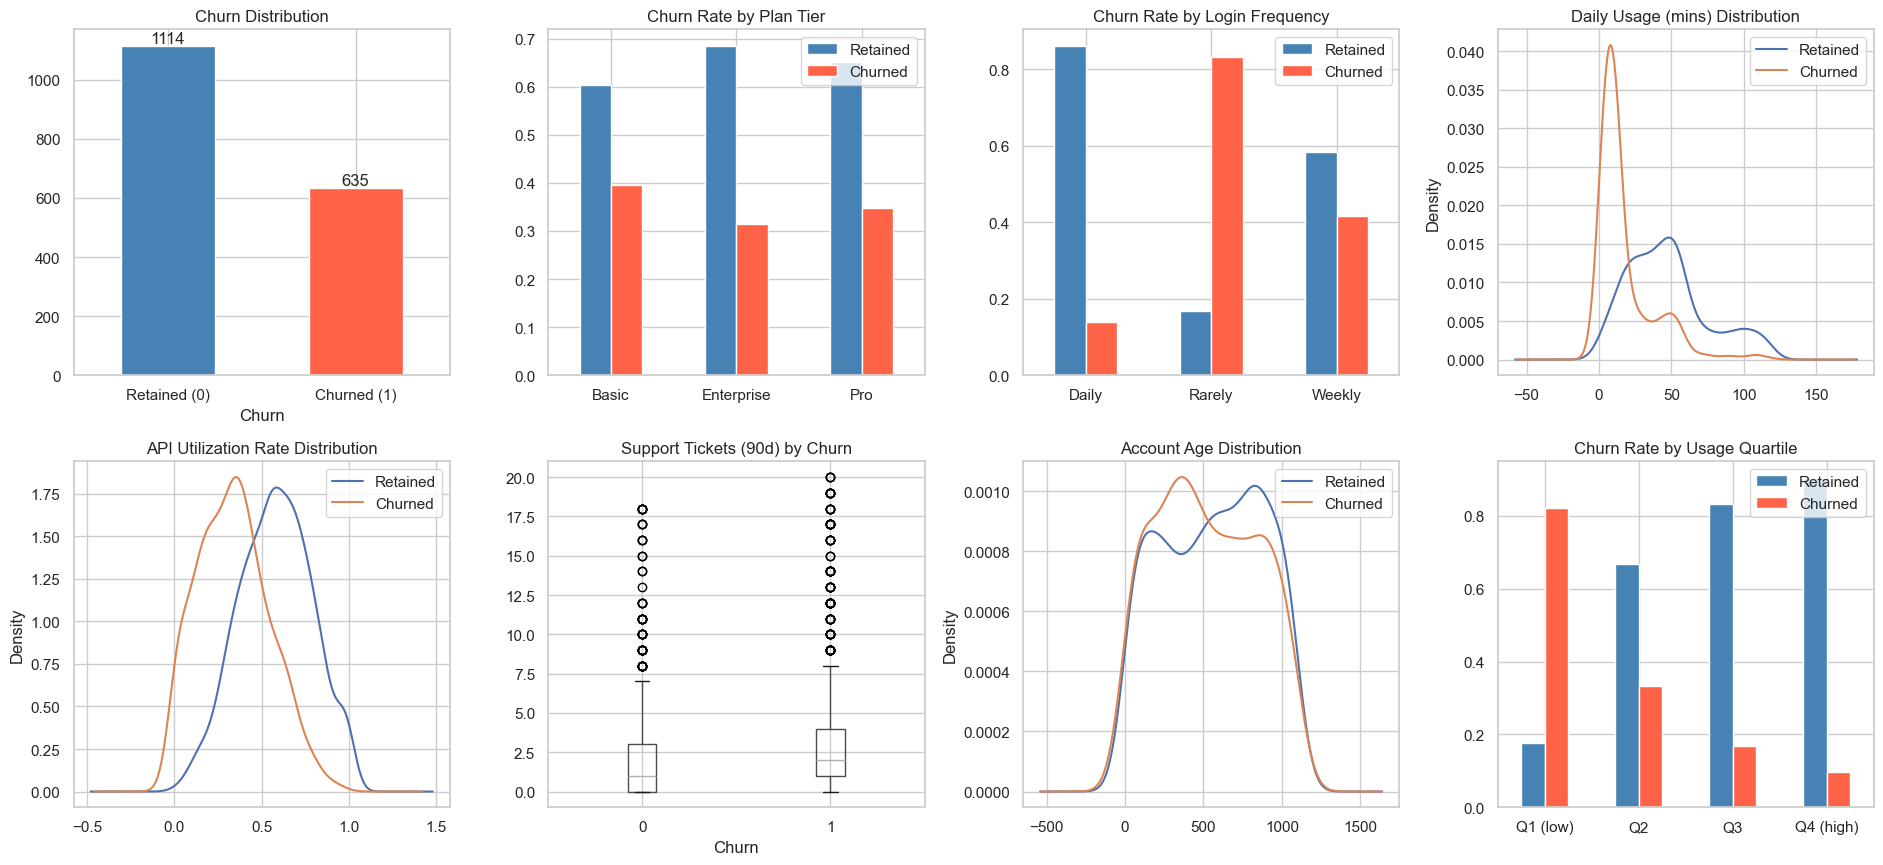

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(19, 9))

# Churn distribution
counts = train['Churn'].value_counts()
counts.plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xticklabels(['Retained (0)', 'Churned (1)'], rotation=0)
for i, v in enumerate(counts):
    axes[0,0].text(i, v + 10, str(v), ha='center')

# Plan Tier vs Churn
pd.crosstab(train['Plan_Tier'], train['Churn'], normalize='index').plot(
    kind='bar', ax=axes[0,1], color=['steelblue','tomato'])
axes[0,1].set_title('Churn Rate by Plan Tier')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(['Retained', 'Churned'])

# Login Frequency vs Churn
pd.crosstab(train['Login_Frequency'], train['Churn'], normalize='index').plot(
    kind='bar', ax=axes[0,2], color=['steelblue','tomato'])
axes[0,2].set_title('Churn Rate by Login Frequency')
axes[0,2].set_xlabel('')
axes[0,2].tick_params(axis='x', rotation=0)
axes[0,2].legend(['Retained', 'Churned'])

# Daily Usage Mins by Churn
for label, grp in train.groupby('Churn'):
    grp['Daily_Usage_Mins'].plot(kind='kde', ax=axes[0,3],
        label='Churned' if label==1 else 'Retained')
axes[0,3].set_title('Daily Usage (mins) Distribution')
axes[0,3].legend()

# API Utilization Rate
for label, grp in train.groupby('Churn'):
    grp['API_Utilization_Rate'].plot(kind='kde', ax=axes[1,0],
        label='Churned' if label==1 else 'Retained')
axes[1,0].set_title('API Utilization Rate Distribution')
axes[1,0].legend()

# Support Tickets 90 Days
train.boxplot(column='Support_Tickets_90Days', by='Churn', ax=axes[1,1])
plt.sca(axes[1,1])
plt.title('Support Tickets (90d) by Churn')
axes[1,1].set_xlabel('Churn')

# Account Age
for label, grp in train.groupby('Churn'):
    grp['Account_Age_Days'].plot(kind='kde', ax=axes[1,2],
        label='Churned' if label==1 else 'Retained')
axes[1,2].set_title('Account Age Distribution')
axes[1,2].legend()

# Churn rate by Daily Usage quartile — turns a continuous feature into
# the same "rate by bucket" view used for the categorical panels above
usage_q = pd.qcut(train['Daily_Usage_Mins'], 4, labels=['Q1 (low)','Q2','Q3','Q4 (high)'])
pd.crosstab(usage_q, train['Churn'], normalize='index').plot(
    kind='bar', ax=axes[1,3], color=['steelblue','tomato'])
axes[1,3].set_title('Churn Rate by Usage Quartile')
axes[1,3].set_xlabel('')
axes[1,3].tick_params(axis='x', rotation=0)
axes[1,3].legend(['Retained', 'Churned'])

plt.suptitle('')
plt.tight_layout()
plt.show()

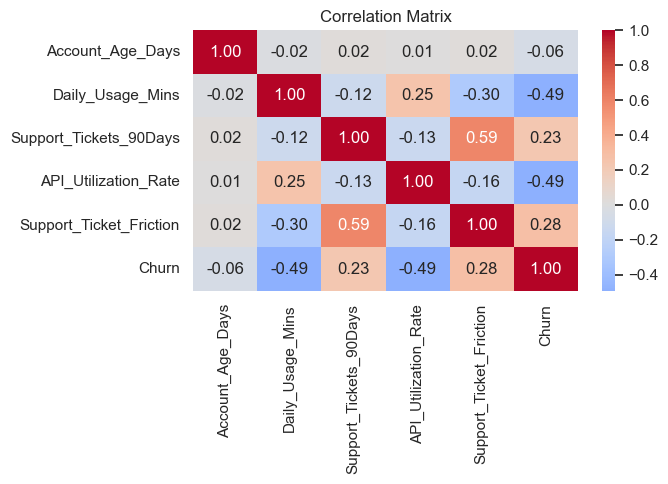

In [6]:
# Correlation heatmap (numeric features only)
numeric_cols = ['Account_Age_Days', 'Daily_Usage_Mins', 'Support_Tickets_90Days',
                'API_Utilization_Rate', 'Support_Ticket_Friction', 'Churn']
plt.figure(figsize=(7, 5))
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [7]:
TARGET = 'Churn'

NUM_FEATURES = ['Account_Age_Days', 'Daily_Usage_Mins',
                'Support_Tickets_90Days', 'API_Utilization_Rate',
                'Support_Ticket_Friction']
CAT_FEATURES = ['Login_Frequency', 'Plan_Tier']

X_train = train[NUM_FEATURES + CAT_FEATURES]
y_train = train[TARGET]

X_val = val[NUM_FEATURES + CAT_FEATURES]
y_val = val[TARGET]

X_test = test[NUM_FEATURES + CAT_FEATURES]
y_test = test[TARGET]

print('X_train:', X_train.shape, '  X_val:', X_val.shape, '  X_test:', X_test.shape)
print('Class balance (train):', y_train.value_counts().to_dict())

X_train: (1749, 7)   X_val: (375, 7)   X_test: (376, 7)
Class balance (train): {0: 1114, 1: 635}


In [8]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
])

In [9]:
# Sample weights for models with no native `class_weight` parameter (Gradient Boosting)
sample_weight_train = compute_sample_weight('balanced', y_train)

# scale_pos_weight for XGBoost: ratio of negative to positive class in the training fold
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Train class counts        — Retained: {neg}, Churned: {pos}')
print(f'scale_pos_weight (XGBoost) = {scale_pos_weight:.3f}')
print(f'sample_weight (GB) range   = [{sample_weight_train.min():.3f}, {sample_weight_train.max():.3f}]')

Train class counts        — Retained: 1114, Churned: 635
scale_pos_weight (XGBoost) = 1.754
sample_weight (GB) range   = [0.785, 1.377]


In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=SEED),
}

if HAS_XGB:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, eval_metric='logloss',
        scale_pos_weight=scale_pos_weight, random_state=SEED
    )

pipelines = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    if name == 'Gradient Boosting':
        # No class_weight param on this estimator — pass the balanced sample weights
        # computed in §4 straight through the pipeline to the classifier step.
        pipe.fit(X_train, y_train, clf__sample_weight=sample_weight_train)
    else:
        pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f'Trained: {name}')

Trained: Logistic Regression
Trained: Random Forest
Trained: Gradient Boosting
Trained: XGBoost


In [11]:
results = []
for name, pipe in pipelines.items():
    y_pred  = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall':    round(recall_score(y_val, y_pred), 4),
        'F1 Score':  round(f1_score(y_val, y_pred), 4),
        # beta=2 weights recall 4x more than precision — the retention team would
        # rather flag a few extra safe customers than miss an actual churner.
        'F2 Score':  round(fbeta_score(y_val, y_pred, beta=2), 4),
        'ROC-AUC':   round(roc_auc_score(y_val, y_proba), 4),
        'PR-AUC':    round(average_precision_score(y_val, y_proba), 4),
    })

results_df = pd.DataFrame(results).sort_values('F2 Score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC
2,Gradient Boosting,0.8373,0.7419,0.8456,0.7904,0.8226,0.9075,0.8532
1,Random Forest,0.8693,0.8271,0.8088,0.8178,0.8124,0.9080,0.8557
0,Logistic Regression,0.8213,0.7379,0.7868,0.7616,0.7765,0.9082,0.8634
3,XGBoost,0.8133,0.7292,0.7721,0.7500,0.7631,0.8836,0.8333


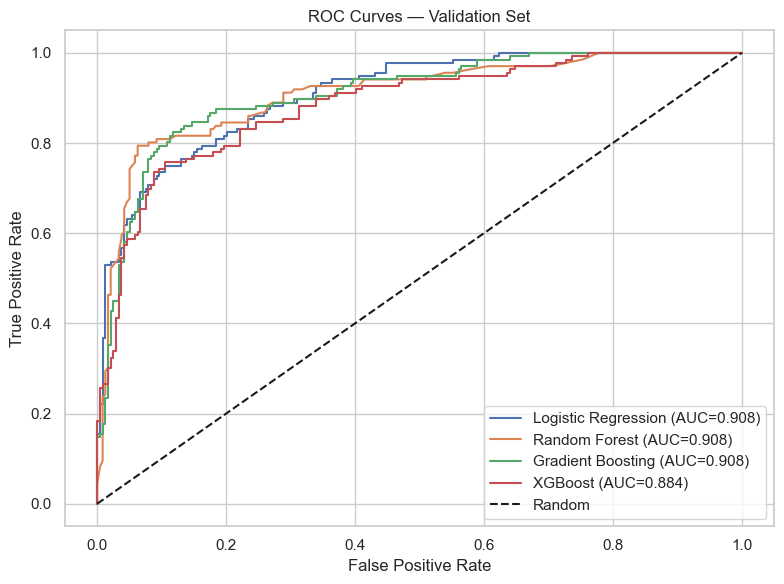

In [12]:
# ROC curves for all models
plt.figure(figsize=(8, 6))
for name, pipe in pipelines.items():
    y_proba = pipe.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Validation Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

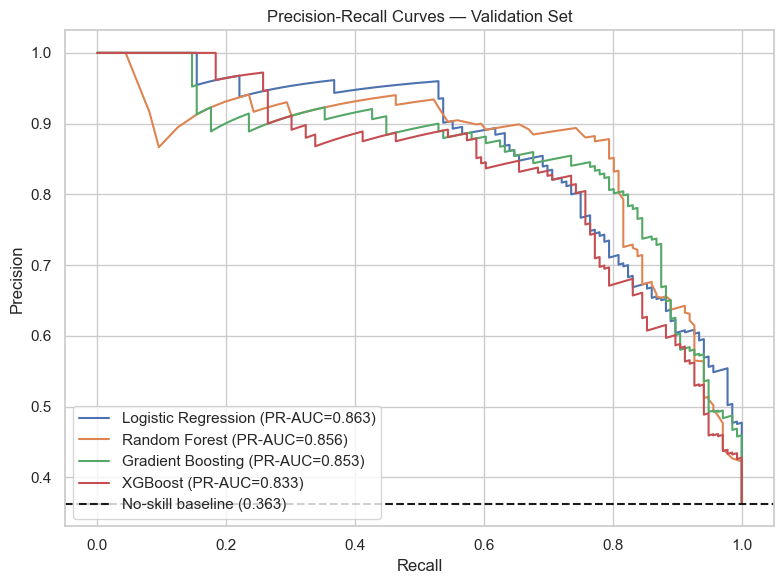

In [13]:
# Precision-Recall curves for all models
plt.figure(figsize=(8, 6))
for name, pipe in pipelines.items():
    y_proba = pipe.predict_proba(X_val)[:, 1]
    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    ap = average_precision_score(y_val, y_proba)
    plt.plot(recall, precision, label=f'{name} (PR-AUC={ap:.3f})')

no_skill = y_val.mean()
plt.axhline(no_skill, color='k', linestyle='--', label=f'No-skill baseline ({no_skill:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Validation Set')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

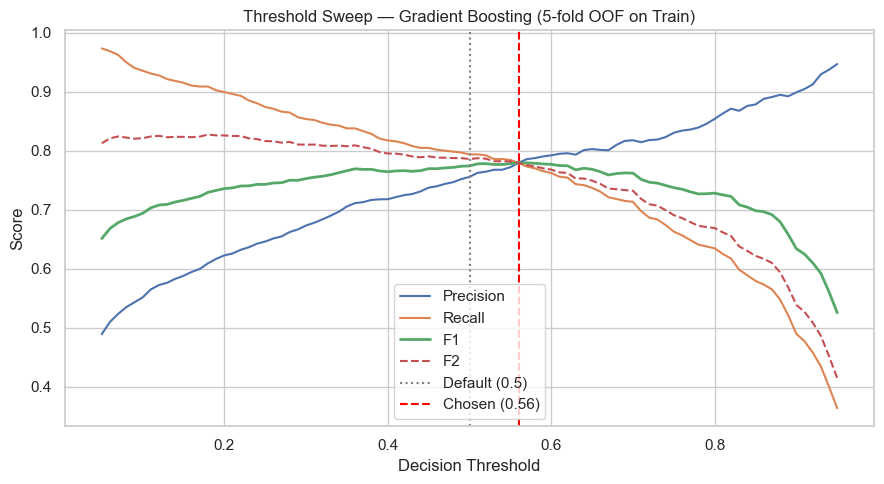

Best model by validation F2 Score: Gradient Boosting
F1-optimal (balanced) threshold (5-fold CV on train): 0.56  (default is 0.5)
At this threshold (OOF, train) — Precision: 0.780  Recall: 0.780  F1: 0.780  F2: 0.780


In [14]:
best_val_name = results_df.iloc[0]['Model']
best_val_pipe = pipelines[best_val_name]
val_proba = best_val_pipe.predict_proba(X_val)[:, 1]

# Threshold is chosen via 5-fold CV on the training set rather than a single sweep
# over the 375-row validation split. With that few rows the F-score-vs-threshold curve
# is noisy enough that the "optimal" threshold doesn't generalize (it previously
# picked 0.6, which on the test set caught FEWER churners than the default 0.5).
# Out-of-fold predictions over the full training set give a much more stable curve.
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone

cv_pipe = clone(pipelines[best_val_name])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# sklearn >=1.4 routes fit params through `params=` (fit_params was removed in 1.6)
fit_params = {'clf__sample_weight': sample_weight_train} if best_val_name == 'Gradient Boosting' else {}

oof_proba = cross_val_predict(
    cv_pipe, X_train, y_train, cv=cv, method='predict_proba', params=fit_params
)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
prec_list, rec_list, f1_list, f2_list = [], [], [], []
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    prec_list.append(precision_score(y_train, pred_t, zero_division=0))
    rec_list.append(recall_score(y_train, pred_t, zero_division=0))
    f1_list.append(f1_score(y_train, pred_t, zero_division=0))
    f2_list.append(fbeta_score(y_train, pred_t, beta=2, zero_division=0))

# The MODEL was picked with F2 (recall matters more when choosing an architecture),
# but the THRESHOLD is a separate decision: it's the one number that has to work as
# a single deployed cutoff, so it's optimized for F1 — the metric that weights
# precision and recall equally — rather than F2, which would push it to an extreme,
# high-recall/low-precision operating point.
best_idx = int(np.argmax(f1_list))
BEST_THRESHOLD = round(float(thresholds[best_idx]), 2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, prec_list, label='Precision')
ax.plot(thresholds, rec_list, label='Recall')
ax.plot(thresholds, f1_list, label='F1', linewidth=2)
ax.plot(thresholds, f2_list, label='F2', linestyle='--')
ax.axvline(0.5, color='gray', linestyle=':', label='Default (0.5)')
ax.axvline(BEST_THRESHOLD, color='red', linestyle='--', label=f'Chosen ({BEST_THRESHOLD})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Sweep — {best_val_name} (5-fold OOF on Train)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best model by validation F2 Score: {best_val_name}')
print(f'F1-optimal (balanced) threshold (5-fold CV on train): {BEST_THRESHOLD}  (default is 0.5)')
print(f'At this threshold (OOF, train) — Precision: {prec_list[best_idx]:.3f}  Recall: {rec_list[best_idx]:.3f}  F1: {f1_list[best_idx]:.3f}  F2: {f2_list[best_idx]:.3f}')

In [15]:
best_name = best_val_name
best_pipe = pipelines[best_name]
print(f'Best model (by validation F2 Score): {best_name}')
print(f'Using tuned threshold: {BEST_THRESHOLD} (default: 0.5)')

y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_tuned   = (y_proba >= BEST_THRESHOLD).astype(int)

print('\nClassification Report — default threshold (0.5):')
print(classification_report(y_test, y_pred_default, target_names=['Retained', 'Churned']))

print('Classification Report — tuned threshold ({:.2f}):'.format(BEST_THRESHOLD))
print(classification_report(y_test, y_pred_tuned, target_names=['Retained', 'Churned']))

y_pred = y_pred_tuned  # used downstream (predictions export, confusion matrix)

Best model (by validation F2 Score): Gradient Boosting
Using tuned threshold: 0.56 (default: 0.5)

Classification Report — default threshold (0.5):
              precision    recall  f1-score   support

    Retained       0.89      0.91      0.90       239
     Churned       0.83      0.81      0.82       137

    accuracy                           0.87       376
   macro avg       0.86      0.86      0.86       376
weighted avg       0.87      0.87      0.87       376

Classification Report — tuned threshold (0.56):
              precision    recall  f1-score   support

    Retained       0.89      0.92      0.90       239
     Churned       0.84      0.80      0.82       137

    accuracy                           0.87       376
   macro avg       0.87      0.86      0.86       376
weighted avg       0.87      0.87      0.87       376



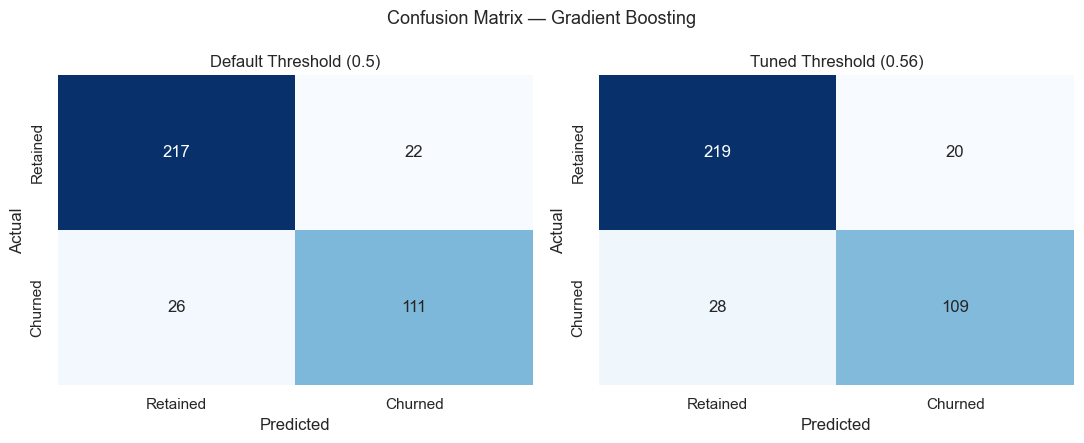

In [16]:
# Confusion matrices — default vs. tuned threshold, side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, preds, title in [
    (axes[0], y_pred_default, f'Default Threshold (0.5)'),
    (axes[1], y_pred_tuned,   f'Tuned Threshold ({BEST_THRESHOLD})'),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'], cbar=False)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle(f'Confusion Matrix — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

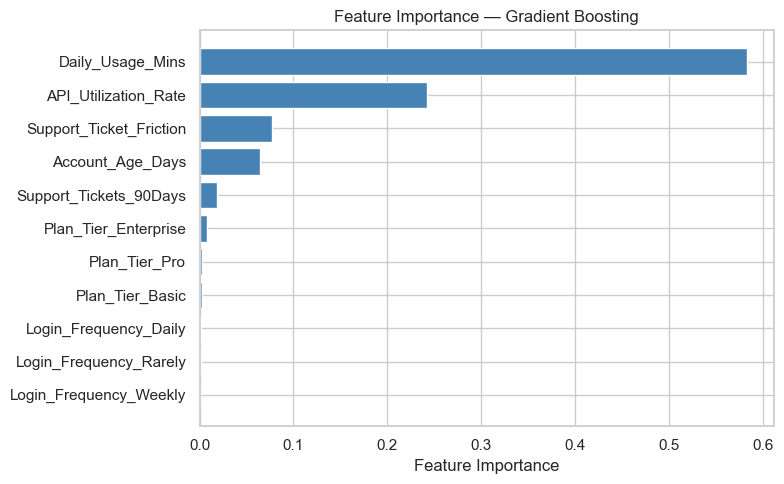

In [17]:
# Get feature names after preprocessing
cat_feature_names = best_pipe.named_steps['prep']\
    .named_transformers_['cat'].get_feature_names_out(CAT_FEATURES).tolist()
all_feature_names = NUM_FEATURES + cat_feature_names

clf = best_pipe.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    kind = 'Feature Importance'
elif hasattr(clf, 'coef_'):
    importances = np.abs(clf.coef_[0])
    kind = '|Coefficient|'
else:
    importances = None

if importances is not None:
    fi_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})\
              .sort_values('Importance', ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
    plt.xlabel(kind)
    plt.title(f'{kind} — {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance not available for this model type.')

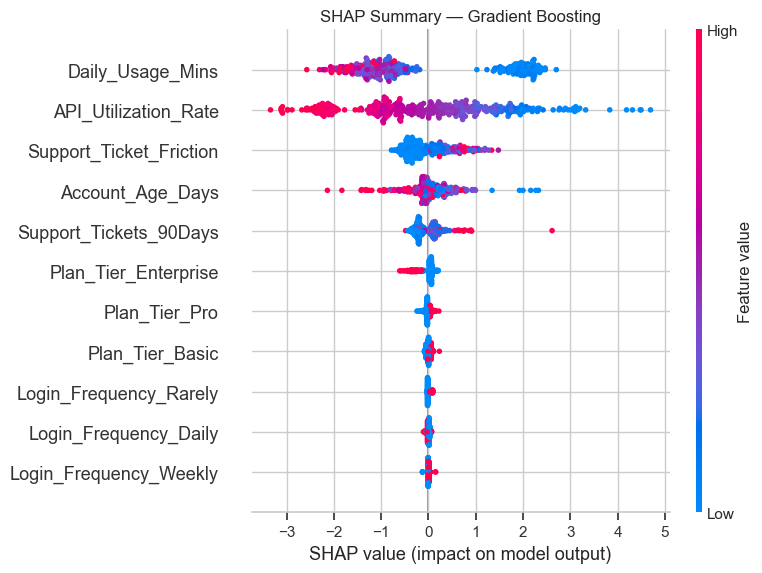

In [18]:
if HAS_SHAP:
    X_val_transformed = best_pipe.named_steps['prep'].transform(X_val)
    background = shap.utils.sample(X_val_transformed, min(100, len(X_val_transformed)), random_state=SEED)

    explainer = shap.Explainer(clf, background, feature_names=all_feature_names)

    # TreeExplainer's additivity check (SHAP values should sum to the model's raw
    # output) can trip a false positive on tree ensembles trained with sample_weight
    # (§4/§5) — the weighting shifts leaf values in a way the fast Tree path doesn't
    # always reconcile exactly. Disabling it for Tree explainers only (via the
    # documented `check_additivity=False` workaround) skips that overly strict check
    # without affecting the SHAP values themselves or non-tree explainer types, which
    # don't accept this argument at all.
    call_kwargs = {'check_additivity': False} if isinstance(explainer, shap.explainers.Tree) else {}
    shap_values = explainer(X_val_transformed, **call_kwargs)

    values = shap_values.values
    if values.ndim == 3:
        # Some estimators (e.g. RandomForestClassifier) return per-class SHAP values;
        # keep the "Churned" (class 1) slice to match every other plot in this notebook.
        values = values[:, :, 1]

    shap.summary_plot(values, X_val_transformed, feature_names=all_feature_names, show=False)
    plt.title(f'SHAP Summary — {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print('SHAP not installed — skipping. Install with `pip install shap` to enable this cell.')

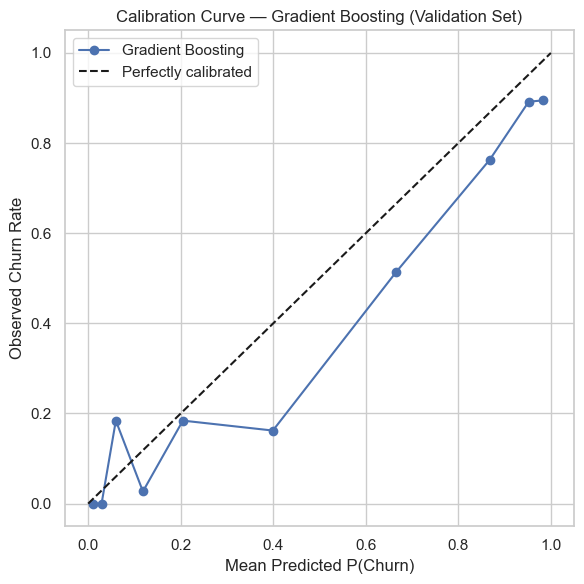

In [19]:
prob_true, prob_pred = calibration_curve(y_val, val_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label=best_val_name)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean Predicted P(Churn)')
plt.ylabel('Observed Churn Rate')
plt.title(f'Calibration Curve — {best_val_name} (Validation Set)')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
test_out = test.copy()
test_out['Churn_Probability']         = y_proba.round(4)
test_out['Churn_Predicted_Default']   = y_pred_default
test_out['Churn_Predicted_Tuned']     = y_pred_tuned
test_out.to_csv('Datasets/test_churn_predictions.csv', index=False)
print('Saved → Datasets/test_churn_predictions.csv')
test_out[['Churn', 'Churn_Probability', 'Churn_Predicted_Default', 'Churn_Predicted_Tuned']].head(10)

Saved → Datasets/test_churn_predictions.csv


,Churn,Churn_Probability,Churn_Predicted_Default,Churn_Predicted_Tuned
2352,0,0.0833,0,0
596,1,0.8935,1,1
339,0,0.0076,0,0
2215,0,0.1072,0,0
1501,0,0.3323,0,0
702,0,0.0407,0,0
2007,1,0.9775,1,1
1369,0,0.6406,1,1
2312,1,0.9709,1,1
1618,1,0.7919,1,1


In [21]:
import joblib, os, json

os.makedirs('models', exist_ok=True)

# Save best model
model_path = f'models/churn_{best_name.lower().replace(" ", "_")}.pkl'
joblib.dump(best_pipe, model_path)
print(f'Best model saved → {model_path}')

# Save all trained pipelines
for name, pipe in pipelines.items():
    path = f'models/churn_{name.lower().replace(" ", "_")}.pkl'
    joblib.dump(pipe, path)
    print(f'Saved → {path}')

# Persist the tuned decision threshold alongside the models
threshold_path = 'models/churn_threshold.json'
with open(threshold_path, 'w') as f:
    json.dump({'best_model': best_name, 'threshold': BEST_THRESHOLD}, f, indent=2)
print(f'Threshold saved → {threshold_path}')

Best model saved → models/churn_gradient_boosting.pkl
Saved → models/churn_logistic_regression.pkl
Saved → models/churn_random_forest.pkl
Saved → models/churn_gradient_boosting.pkl
Saved → models/churn_xgboost.pkl
Threshold saved → models/churn_threshold.json


In [22]:
# Verify: reload best model and confirm predictions are identical
loaded_model = joblib.load(model_path)
assert (loaded_model.predict(X_test) == best_pipe.predict(X_test)).all(), 'Mismatch after reload!'
print(f'Verification passed — reloaded model predictions match original.')
print(f'Model ready to use: {model_path}')

Verification passed — reloaded model predictions match original.
Model ready to use: models/churn_gradient_boosting.pkl
